In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install rdkit

In [3]:
import sys
sys.path.append("/content/drive/MyDrive/CompDReAM/src")
from functions import smiles_to_morgan_fp, fetch_uniprot_sequences, batch_embed_sequences

# Core libraries
import pandas as pd
import numpy as np
import json
import time
import requests
import os
import glob
from math import sqrt
from datetime import datetime

# RDKit
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, MACCSkeys, rdFMCS
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs.cDataStructs import ConvertToNumpyArray
from rdkit.ML.Descriptors import MoleculeDescriptors

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, r2_score, roc_auc_score, f1_score)
from sklearn.base import clone
import joblib

# PyTorch (ProtBERT)
import torch
from torch.utils.data import DataLoader

# Transformers (ProtBERT)
from transformers import BertTokenizer, BertModel

# Visual
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from IPython.display import display
from tqdm import tqdm

In [4]:
df = pd.read_csv("/content/drive/MyDrive/CompDReAM/training_dataset.csv", low_memory=False)
df = df.dropna(subset=["Canonical SMILES", "UniProt", "pChEMBL"]).reset_index(drop=True)
model_path = "/content/drive/MyDrive/CompDReAM/rf_model.pkl"

generator = GetMorganGenerator(radius=2, fpSize=2048)

fps, valid_idx = [], []
for idx, s in enumerate(df["Canonical SMILES"]):
    arr = smiles_to_morgan_fp(s)
    if arr is not None:
        fps.append(arr)
        valid_idx.append(idx)

df = df.iloc[valid_idx].reset_index(drop=True)
X_mol = np.array(fps)

all_uniprots = df["UniProt"].dropna().str.split(",").explode().str.strip().unique().tolist()
cache_file = "/content/drive/MyDrive/CompDReAM/id_to_seq.json"

if os.path.exists(cache_file):
    print(f"✓ Loading sequences from cache: {cache_file}")
    with open(cache_file) as f:
        id_to_seq = json.load(f)
else:
    print("✗ Cache not found — fetching sequences from UniProt API...")
    id_to_seq = fetch_uniprot_sequences(all_uniprots)
    with open(cache_file, "w") as f:
        json.dump(id_to_seq, f)
    print(f"✓ Sequences fetched and saved to: {cache_file}")

tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert").eval()

df["UniProt_List"] = df["UniProt"].str.split(",").apply(lambda lst: [i.strip() for i in lst])
df["BestUniProt"] = df["UniProt_List"].apply(lambda lst: lst[0])  # choose first UniProt ID
df["Sequence"] = df["BestUniProt"].map(id_to_seq)
valid_seq_mask = df["Sequence"].notna()
sequences = df.loc[valid_seq_mask, "Sequence"].tolist()

prot_cache_path = "/content/drive/MyDrive/CompDReAM/protbert/X_prot.npy"
batch_prefix = "/content/drive/MyDrive/CompDReAM/protbert/protbert_batch"
if os.path.exists(prot_cache_path):
    print(f"✓ Loaded final cached embeddings: {prot_cache_path}")
    X_prot = np.load(prot_cache_path)
else:
    print("✗ Final cache not found — checking for batch fragments...")
    batch_files = sorted(glob.glob(f"{batch_prefix}_*.npy"))
    if batch_files:
        print(f"✓ Found {len(batch_files)} cached batches. Merging with np.memmap...")
        # Load one batch to determine shape
        sample = np.load(batch_files[0], mmap_mode="r")
        dim = sample.shape[1]
        total_rows = sum(np.load(f, mmap_mode="r").shape[0] for f in batch_files)
        # Create memmap-backed array on disk
        X_prot_memmap = np.memmap(prot_cache_path, dtype='float32', mode='w+', shape=(total_rows, dim))
        # Fill it incrementally without holding anything big in memory
        i = 0
        for path in tqdm(batch_files, desc="Merging batches"):
            batch = np.load(path, mmap_mode="r")
            n = batch.shape[0]
            X_prot_memmap[i:i+n, :] = batch
            i += n
        del X_prot_memmap  # Save and flush to disk
        print(f"✓ ProtBERT embeddings saved to: {prot_cache_path}")
        X_prot = np.load(prot_cache_path)
    else:
        print("✗ No batch fragments found — computing embeddings...")
        X_prot = batch_embed_sequences(sequences, cache_prefix=batch_prefix)
        np.save(prot_cache_path, X_prot)
        print(f"✓ ProtBERT embeddings saved to: {prot_cache_path}")

df = df.loc[valid_seq_mask].reset_index(drop=True)
X_mol = X_mol[valid_seq_mask.values]
y = df["pChEMBL"].astype(float).values

X_combined_path = "/content/drive/MyDrive/CompDReAM/protbert/X_combined.npy"
y_path = "/content/drive/MyDrive/CompDReAM/protbert/y.npy"
n_samples = X_mol.shape[0]
combined_shape = (n_samples, X_mol.shape[1] + X_prot.shape[1])
if os.path.exists(X_combined_path) and os.path.exists(y_path):
    print(f"✓ Loading existing X and y from disk.")
    X = np.memmap(X_combined_path, dtype=np.float32, mode="r", shape=combined_shape)
    y = np.load(y_path)
else:
    print("✗ Cache not found — creating X_combined.npy and y.npy")
    X_combined = np.memmap(X_combined_path, dtype=np.float32, mode="w+", shape=combined_shape)
    X_combined[:, :X_mol.shape[1]] = X_mol
    X_combined[:, X_mol.shape[1]:] = X_prot
    X_combined.flush()
    np.save(y_path, y)
    print("✓ Features and labels saved.")
    X = np.memmap(X_combined_path, dtype=np.float32, mode="r", shape=combined_shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if os.path.exists(model_path):
    print("✓ Loading pre-trained model...")
    rf = joblib.load(model_path)
else:
    print("✗ No pre-trained model found. Training from scratch...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    joblib.dump(rf, model_path)
    print(f"✓ Model saved to: {model_path}")

y_pred = rf.predict(X_test)
print("Train R²:", rf.score(X_train, y_train))
print("Test R²:", r2_score(y_test, y_pred))
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred)))

[09:08:09] WARNING: not removing hydrogen atom without neighbors


✓ Loading sequences from cache: /content/drive/MyDrive/CompDReAM/id_to_seq.json


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✓ Loaded final cached embeddings: /content/drive/MyDrive/CompDReAM/protbert/X_prot.npy
✓ Loading existing X and y from disk.
✓ Loading pre-trained model...
Train R²: 0.9275406102339719
Test R²: 0.7336684504937602
RMSE: 0.5274451172007724


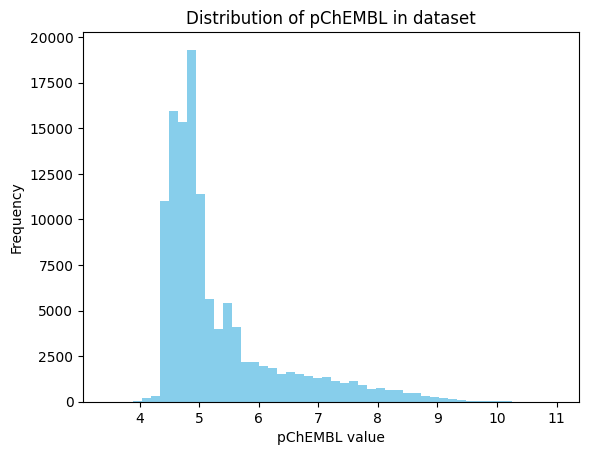

In [5]:
plt.hist(y, bins=50, color="skyblue")
plt.xlabel("pChEMBL value")
plt.ylabel("Frequency")
plt.title("Distribution of pChEMBL in dataset")
plt.show()

In [6]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (94916, 3072)
Shape of X_test: (23730, 3072)
Shape of y_train: (94916,)
Shape of y_test: (23730,)


In [11]:
# Get top and bottom contributors
import numpy as np
top_idx = np.argsort(y_pred)[-10:]  # Top 10 pChEMBL predictions
bottom_idx = np.argsort(y_pred)[:10]  # Bottom 10 pChEMBL predictions

highlight_idxs = np.concatenate([top_idx, bottom_idx])
X_focus = X_test[highlight_idxs]
explainer = shap.TreeExplainer(rf)

shap_values_focus = explainer.shap_values(X_focus)

# Plot dot plot or force plot
shap.summary_plot(shap_values_focus, X_focus, max_display=15)


ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was -109309804803880217825086688341840613966120878516783570571190756904698465465925632.000000, while the model output was 4.270900. If this difference is acceptable you can set check_additivity=False to disable this check.